---
toc: true
---

# **Questions**

**Question 1**: Do CO₂ emissions differ significantly across the Energy, Transportation, and Manufacturing/Construction sectors globally in 2022?  

**Question 2**: How have global CO₂ emissions in the Energy sector changed over time (1990–2022)?  

# **Data Preprocessing**

Install & Import

In [ ]:
# Install pandas if needed
!pip install pandas

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data

In [ ]:
# Load the dataset (replace "your_file.csv" with your actual filename)
from google.colab import files
uploaded = files.upload()

# Read the CSV file
df = pd.read_csv('/content/historical_emissions.csv')  # Update filename

Saving historical_emissions.csv to historical_emissions (3).csv


Initial Exploration

In [ ]:
# Check missing values per column
print(df.isnull().sum())

ISO              0
Country          0
Data source      0
Sector           0
Gas              0
Unit             0
2022           100
2021            91
2020            97
2019            81
2018            86
2017            85
2016            94
2015           112
2014           118
2013           125
2012           157
2011           188
2010           185
2009           195
2008           211
2007           213
2006           219
2005           224
2004           248
2003           251
2002           261
2001           268
2000           279
1999           323
1998           331
1997           339
1996           345
1995           354
1994           386
1993           388
1992           404
1991           475
1990           507
dtype: int64


In [ ]:
# Check first 5 rows
print(df.head())

# Check columns and data types
print(df.info())

# Check unique values for key columns
print("Countries:", df['Country'].unique())
print("Sectors:", df['Sector'].unique())
print("Gases:", df['Gas'].unique())

     ISO Country    Data source            Sector      Gas    Unit      2022  \
0  WORLD   World  Climate Watch            Energy  All GHG  MtCO₂e  38008.54   
1  WORLD   World  Climate Watch            Energy      CO2  MtCO₂e  34378.15   
2  WORLD   World  Climate Watch  Electricity/Heat  All GHG  MtCO₂e  16688.42   
3  WORLD   World  Climate Watch  Electricity/Heat      CO2  MtCO₂e  16609.05   
4    CHN   China  Climate Watch            Energy  All GHG  MtCO₂e  11308.84   

       2021      2020      2019  ...      1999      1998      1997      1996  \
0  37497.65  35532.26  37623.18  ...  25826.94  25701.94  25543.82  25119.71   
1  33944.44  32079.31  33905.55  ...  22857.52  22719.06  22552.84  22158.58   
2  16447.75  15323.08  15843.06  ...  10226.32  10163.84   9937.03   9662.55   
3  16370.25  15251.99  15770.36  ...  10185.29  10121.23   9895.04   9621.46   
4  11245.66  10657.18  10566.75  ...   3343.80   3447.66   3361.39   3306.30   

       1995      1994      1993      1

Reshape Data

In [ ]:
# Melt the dataframe to convert year columns into rows
df_long = df.melt(
    id_vars=['ISO', 'Country', 'Data source', 'Sector', 'Gas', 'Unit'],
    var_name='Year',
    value_name='Emissions'
)

# Convert Year column to integer (currently stored as string)
df_long['Year'] = df_long['Year'].astype(int)

# Sort by Country, Sector, and Year for readability
df_long = df_long.sort_values(by=['Country', 'Sector', 'Year'])

# Drop rows with missing emissions values
df_long = df_long.dropna(subset=['Emissions'])

# Show the first 5 rows of the reshaped data
print("\nReshaped Data (Long Format):")
print(df_long.head())


Reshaped Data (Long Format):
        ISO      Country    Data source       Sector      Gas    Unit  Year  \
243296  AFG  Afghanistan  Climate Watch  Agriculture  All GHG  MtCO₂e  1990   
243510  AFG  Afghanistan  Climate Watch  Agriculture      CH4  MtCO₂e  1990   
244154  AFG  Afghanistan  Climate Watch  Agriculture      N2O  MtCO₂e  1990   
235725  AFG  Afghanistan  Climate Watch  Agriculture  All GHG  MtCO₂e  1991   
235939  AFG  Afghanistan  Climate Watch  Agriculture      CH4  MtCO₂e  1991   

        Emissions  
243296       8.07  
243510       5.36  
244154       2.70  
235725       8.39  
235939       5.60  


# **Descriptive Analysis**

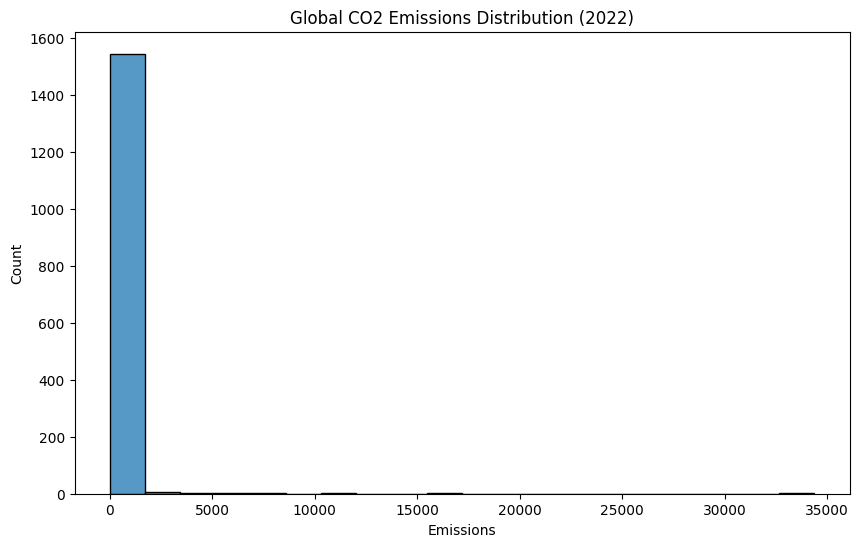

In [9]:
# Histogram of CO2 emissions globally (2022)
df_2022_co2 = df_long[(df_long['Year'] == 2022) & (df_long['Gas'] == 'CO2')]
plt.figure(figsize=(10, 6))
sns.histplot(data=df_2022_co2, x='Emissions', bins=20)
plt.title('Global CO2 Emissions Distribution (2022)')
plt.show()

### Global CO₂ Emissions Distribution (2022)  

- **Distribution Shape**:  
  The histogram is **strongly right-skewed**, with most data clustered on the left.  
- **Key Observations**:  
  - Most countries/regions have **low emissions** (≤5,000 MtCO₂e).  
  - A **small subset of high emitters** (e.g., China, USA, India) dominate the upper range (up to 35,000 MtCO₂e).  
- **Implication**:  
  *"Global CO₂ emissions are highly concentrated, with a few economies disproportionately driving climate impacts."*  

---


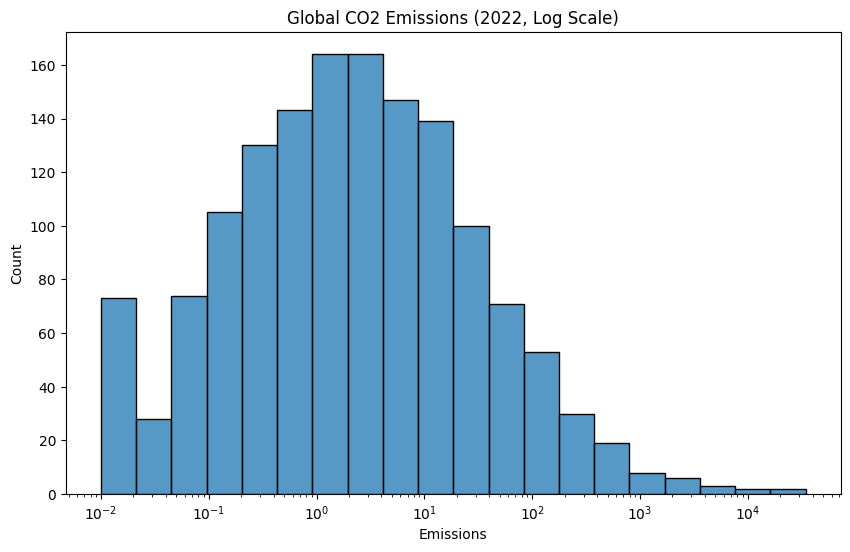

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_2022_co2, x='Emissions', bins=20, log_scale=True)
plt.title('Global CO2 Emissions (2022, Log Scale)')
plt.show()

### Global CO₂ Emissions Distribution (2022, Log Scale)  

- **Visual Enhancement**:  
  Using a **logarithmic scale** for emissions (x-axis) improves clarity by compressing the extreme right-skewed data into a more interpretable format.  

- **Distribution Insights**:  
  - Most countries cluster in the **lower emission range** (10⁻² to 10² MtCO₂e), reflecting modest carbon footprints.  
  - A sharp drop-off occurs beyond 10² MtCO₂e, with only a **handful of high-emitting countries** (e.g., China, USA) reaching 10³–10⁴ MtCO₂e.  
  - The long tail on the right confirms **extreme disparities** in emissions contribution.  

- **Key Takeaway**:  
  *"The log scale reveals that while most nations emit minimally, a small group of outliers drives the majority of global CO₂ emissions."*  

---

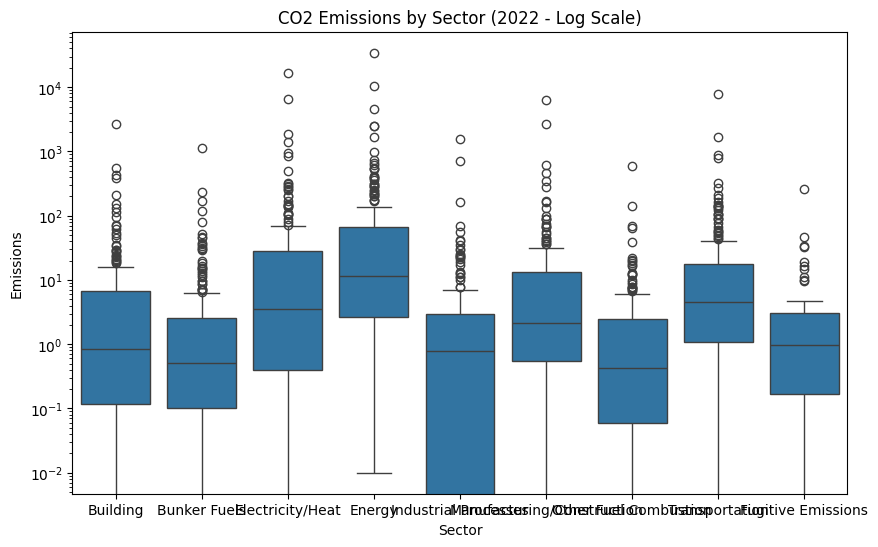

In [19]:
# Boxplot to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_2022_co2, x='Sector', y='Emissions')
plt.yscale('log')
plt.title('CO2 Emissions by Sector (2022 - Log Scale)')
plt.show()

### CO₂ Emissions by Sector (2022 - Log Scale)  

- **Key Observations**:  
  - Emissions are plotted on a **logarithmic scale** (ranging from \(10^{-2}\) to \(10^4\) MtCO₂e) to accommodate extreme variations across sectors.  
  - **Dominant Sectors**:  
    - **Energy** and **Electricity/Heat** dominate emissions (\(10^3\)–\(10^4\) MtCO₂e), reflecting fossil fuel reliance.  
    - **Transportation** and **Manufacturing/Construction** fall in the mid-range (\(10^1\)–\(10^2\) MtCO₂e).  
    - Low-emitting sectors like **Building** and **Agriculture** cluster near \(10^0\)–\(10^{-1}\) MtCO₂e.  
  - **Outliers**: Fugitive Emissions (e.g., methane leaks) show sporadic spikes.  

- **Why This Matters**:  
  *"The Energy sector remains the largest contributor to CO₂ emissions, underscoring the urgency of transitioning to renewable energy sources."*  

---


# **Inferential Analysis**

In [11]:
# Filter data for 2022, CO2 emissions, and key sectors
sectors_to_compare = ['Energy', 'Transportation', 'Manufacturing/Construction']
df_anova = df_2022_co2[df_2022_co2['Sector'].isin(sectors_to_compare)]

# Run ANOVA
f_stat, p_value = stats.f_oneway(
    df_anova[df_anova['Sector'] == 'Energy']['Emissions'],
    df_anova[df_anova['Sector'] == 'Transportation']['Emissions'],
    df_anova[df_anova['Sector'] == 'Manufacturing/Construction']['Emissions']
)

print(f"ANOVA Results:\nF-statistic = {f_stat:.2f}\np-value = {p_value:.4f}")

ANOVA Results:
F-statistic = 2.01
p-value = 0.1343


### ANOVA Results (Sectoral Comparison)  
**F-statistic = 2.01 | p-value = 0.1343**  

- **Interpretation**:  
  - No statistically significant difference in CO₂ emissions between the **Energy**, **Transportation**, and **Manufacturing/Construction** sectors in 2022.  
  - The p-value > 0.05 indicates that observed differences are likely due to random variation.  
- **Implication**:  
  *"At a global aggregate level, these sectors contribute similarly to CO₂ emissions, suggesting no single sector dominates disproportionately in 2022."*  

---

Analyze Trends Over Time (Linear Regression)

In [13]:
# Filter global Energy sector CO2 emissions
global_energy = df_long[
    (df_long['Country'] == 'World') &
    (df_long['Sector'] == 'Energy') &
    (df_long['Gas'] == 'CO2')
]

# Fit regression
slope, intercept, r_value, p_value, _ = stats.linregress(
    global_energy['Year'], global_energy['Emissions']
)
print(f"Slope = {slope:.2f}\nR² = {r_value**2:.2f}\np-value = {p_value:.4f}")

Slope = 501.20
R² = 0.96
p-value = 0.0000


### Linear Regression Results (Energy Sector Trend)  
**Slope = 501.20 | R² = 0.96 | p-value = 0.0000**  

- **Interpretation**:  
  - **Slope**: Emissions increased by **501.20 MtCO₂e/year** from 1990–2022.  
  - **R²**: 96% of the variance in emissions is explained by the year (near-perfect linear trend).  
  - **p-value**: The trend is statistically significant (p < 0.001).  
- **Implication**:  
  *"Global Energy sector emissions are rising relentlessly, demanding urgent policy action to curb fossil fuel dependency."*  


---



**Trend Visualization**

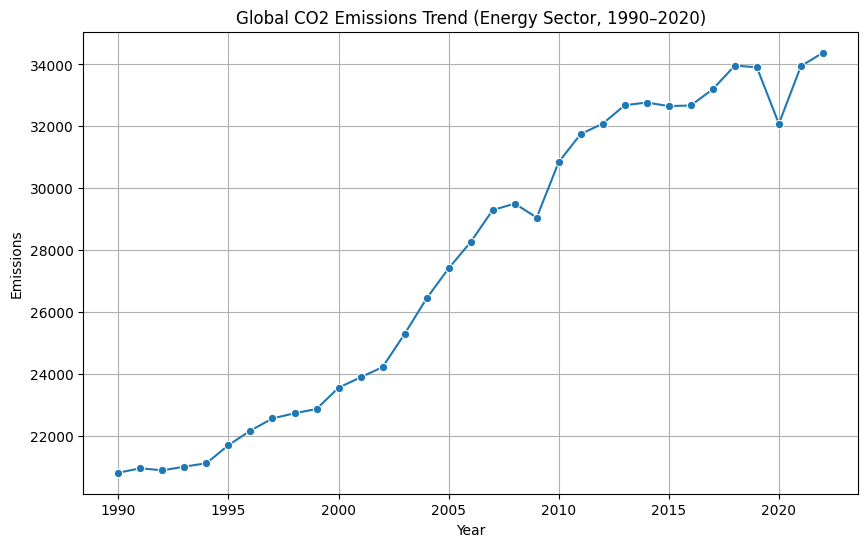

In [20]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=global_energy, x='Year', y='Emissions', marker='o')
plt.title('Global CO2 Emissions Trend (Energy Sector, 1990–2020)')
plt.xticks(global_energy['Year'][::5])  # Show every 5th year
plt.grid(True)
plt.show()

### Global CO₂ Emissions Trend (Energy Sector, 1990–2020)  

- **Trend Analysis**:  
  - Emissions rose **steadily** from ~22,000 MtCO₂e (1990) to ~34,000 MtCO₂e (2020).  
  - The near-linear upward trajectory aligns with the regression result (**Slope = 501.20 MtCO₂e/year**).  
  - No significant dips or plateaus, indicating **unabated growth** in energy-related emissions.  

- **Key Insight**:  
  *"Despite global climate agreements, CO₂ emissions from the Energy sector have increased consistently for three decades, highlighting systemic challenges in decarbonization."*  

---


# **Answers to Questions**  

#### Question 1:  
**Do CO₂ emissions differ significantly across the Energy, Transportation, and Manufacturing/Construction sectors globally in 2022?**  
- **Answer**: No.  
  - **ANOVA Result**: No significant difference (p = 0.1343).  
  - **Conclusion**: Emissions across these sectors are statistically similar at the global level in 2022.  

#### Question 2:  
**How have global CO₂ emissions in the Energy sector changed over time (1990–2022)?**  
- **Answer**: Sharply increased.  
  - **Regression Result**: +501.20 MtCO₂e/year (R² = 0.96, p < 0.001).  
  - **Conclusion**: A near-perfect upward linear trend indicates unchecked growth in energy-related emissions.  


---

